# **Étude de marché internationale : La poule qui chante**

### **Partie 2 : Analyse en Composantes Principales, Clustering et Recommandations**

<center>
    <img src="img/poule_chante_logo.png" width="200">
</center>

⚠️ **Avertissement** : 

Ce document est le second des deux notebooks qui composent notre étude de marché internationale. La liste de pays potentiels pour envisager **la conquête de nouveaux territoires représente 160 pays.**

Nous allons ainsi réaliser des algorithmes de Machine Learning (ACP et Clustering) en utilisant **9 variables** permettant de **cibler quelques pays finaux pour cette stratégie de développement à l'internationale**.  

La préparation, le nettoyage et l'analyse exploratoire des données (EDA) des 160 pays se trouve dans le premier fichier intitulé 01_preparation_donnees.ipynb. 

----

**Contexte de la mission** : 

Nous travaillons au sein de "La Poule Qui Chante", une entreprise d’agroalimentaire française dont l’activité principale est l’élevage et la vente de volailles haut de gamme sous le label Agriculture Biologique (AB).

Notre succès sur le territoire national n'est plus à démontrer, notre ambition est désormais de nous développer à l'international. À ce stade du projet, le champ des possibles est totalement ouvert : aucun continent ni pays cible n'a été présélectionné, le monde entier est envisageable !

**Notre mission** : utiliser la donnée et les indicateurs macro-économiques mondiaux pour déceler, en toute objectivité, les marchés étrangers présentant le meilleur potentiel d'accueil pour nos produits premium.

------

**Sources des données et dictionnaire des variables retenues** : 

Pour garantir la fiabilité de notre analyse, nous nous appuyons sur des bases de données institutionnelles ouvertes (Open Data) :

- **FAO** (Food and Agriculture Organization) & **Banque Mondiale** : Pour les bilans alimentaires, les dynamiques d'import/export de volaille, la démographie, ainsi que les indicateurs macro-économiques (PIB) et de gouvernance (stabilité politique).

- **Université de Yale** (Score EPI) : Pour l'indice de performance environnementale, pour cibler un marché réceptif au "Bio".


Après une analyse PESTEL (Politique, Économique, Sociologique, Technologique, Environnemental, Légal) de notre offre et de nos besoins logistiques, nous avons isolé 9 indicateurs clés qui composeront notre matrice d'analyse :

| Nom de la variable   | Intitulé fonctionnel                 |      Description & enjeu métier                                                                                              |
| ----------------------------------- | -------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------ |
| `population_totale_2017`                 | Population du pays                     | Taille du marché pour évaluer le volume de consommateurs potentiels.                                                 |
| `croissance_demo_2012_2017_pct`                   | Évolution démographique de 2012 à 2017 (en %)                   | Dynamique du marché pour indiquer si la clientèle potentielle est en forte expansion.                                                |
| `pib_habitant_usd`                  | PIB par habitant (en US$)              | Pouvoir d'achat pour évaluer la capacité à acheter un produit Bio (plus cher).                                 |
| `conso_volaille_kg_hab`                | Consommation de volaille par habitant | Consommation de volaille pour confirmer que le pays consomme traditionnellement du poulet.                                         |
| `importations_volaille_kg`             | Importations de volaille (Kilo)      | Ouverture commerciale pour voir si il y a une dépendance et un marché déjà ouvert à l'international.    |
| `tdi_volaille_pct`               | Taux de dépendance aux Importations (en %) | Pays dépendants aux importations de volaille ou non [TDI =(Importations) / (Production + Importations)*100].                                    |
| `conso_volaille_pct`               | Par de la consommation de volaille (en %)          | Part de consommation de volaille par rapport aux autres viandes (boeuf, porc).                   |
| `indice_stabilite_politique`               | Indice de stabilité politique          | Risque politique pour sécuriser les contrats d'exportation et la chaîne logistique.                   |
| `indice_score_epi`                         | Indice de Performance Environnementale | Sensibilité écologique pour identifier les pays sensibles aux produits certifiés Agriculture Biologique. |

<div style="background-color: RGB(127,148,128);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 1 - Import des librairies et des données</h2>
</div>

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.1 - Import des librairies</h3>
</div>

In [1]:
# Import des librairies
import pandas as pd
import numpy as np
from IPython.display import display

from sklearn import datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">1.2 - Import du fichier des 160 pays avec les 9 variables</h3>
</div>

In [2]:
df_analyse = pd.read_csv(
    "../notebooks/csv_finaux/Fichier_Preparatoire_LaPouleQuiChante_11-03-2026.csv"
)
df_analyse = df_analyse.set_index("pays")
print(f"Dimensions : {df_analyse.shape[0]} lignes & {df_analyse.shape[1]} colonnes")
df_analyse.head()

Dimensions : 160 lignes & 9 colonnes


,population_totale_2017,croissance_pop_2012_2017_pct,pib_habitant_usd,indice_stabilite_politique,indice_score_epi,conso_volaille_kg_hab,conso_volaille_pct,importations_volaille_kg,tdi_volaille_pct
pays,,,,,,,,,
Afghanistan,36296113.0,16.478,533.339,-2.79,37.74,1.53,17.81,29000000.0,50.88
Afrique du Sud,57009756.0,7.906,6612.920,-0.28,44.73,35.69,59.47,514000000.0,23.57
Albanie,2884169.0,-1.027,4492.285,0.37,65.46,16.36,34.43,38000000.0,74.51
Algérie,41389189.0,10.714,4080.111,-0.92,57.18,6.38,35.35,2000000.0,0.72
Allemagne,82658409.0,2.082,45281.719,0.57,78.37,19.47,22.18,842000000.0,35.74


<div style="background-color: RGB(127,148,128);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 2 - Analyse en Composantes Principales (ACP) </h2>
</div>

Avec 9 indicateurs macro-économiques par pays, l'analyse directe est complexe. 

L'ACP va nous permettre de réduire ces dimensions pour synthétiser l'information mondiale sur quelques axes majeurs et éliminer le bruit statistique.

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.1 - Séparation des données</h3>
</div>

In [3]:
# Séparation des données avec X la matrice des données
X = df_analyse.to_numpy()
X[:5]

array([[ 3.6296113e+07,  1.6478000e+01,  5.3333900e+02, -2.7900000e+00,
         3.7740000e+01,  1.5300000e+00,  1.7810000e+01,  2.9000000e+07,
         5.0880000e+01],
       [ 5.7009756e+07,  7.9060000e+00,  6.6129200e+03, -2.8000000e-01,
         4.4730000e+01,  3.5690000e+01,  5.9470000e+01,  5.1400000e+08,
         2.3570000e+01],
       [ 2.8841690e+06, -1.0270000e+00,  4.4922850e+03,  3.7000000e-01,
         6.5460000e+01,  1.6360000e+01,  3.4430000e+01,  3.8000000e+07,
         7.4510000e+01],
       [ 4.1389189e+07,  1.0714000e+01,  4.0801110e+03, -9.2000000e-01,
         5.7180000e+01,  6.3800000e+00,  3.5350000e+01,  2.0000000e+06,
         7.2000000e-01],
       [ 8.2658409e+07,  2.0820000e+00,  4.5281719e+04,  5.7000000e-01,
         7.8370000e+01,  1.9470000e+01,  2.2180000e+01,  8.4200000e+08,
         3.5740000e+01]])

In [4]:
# Vérification du type
type(X)

numpy.ndarray

In [5]:
# Vérification de la forme de cette matrice
X.shape

(160, 9)

In [6]:
# Enregistrement des noms de nos pays dans une variable "pays"
pays = df_analyse.index
pays

Index(['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne',
       'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Argentine',
       'Arménie',
       ...
       'Tunisie', 'Turquie', 'Turkménistan', 'Ukraine', 'Uruguay', 'Vanuatu',
       'Venezuela (République bolivarienne du)', 'Viet Nam', 'Zambie',
       'Zimbabwe'],
      dtype='str', name='pays', length=160)

In [7]:
# Enregistrement de nos colonnes, features dans une variable "indicateurs"
indicateurs = df_analyse.columns
indicateurs

Index(['population_totale_2017', 'croissance_pop_2012_2017_pct',
       'pib_habitant_usd', 'indice_stabilite_politique', 'indice_score_epi',
       'conso_volaille_kg_hab', 'conso_volaille_pct',
       'importations_volaille_kg', 'tdi_volaille_pct'],
      dtype='str')

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.2 - Scaling des données</h3>
</div>

In [8]:
# Initialisation du scaler
scaler = StandardScaler()

In [9]:
# Entraînement et ajustement
scaler.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [10]:
# Transformation
X_scaled = scaler.transform(X)
X_scaled[:5]

array([[-4.99430796e-04,  1.39925237e+00, -6.96108707e-01,
        -3.11663737e+00, -1.50718276e+00, -1.18727997e+00,
        -1.12175332e+00, -3.14441536e-01,  4.70407993e-01],
       [ 1.80820230e-01,  1.19622003e-01, -3.73197668e-01,
        -2.33135705e-01, -9.60188736e-01,  1.02933179e+00,
         9.04154265e-01,  2.41799555e+00, -3.26533252e-01],
       [-2.92975378e-01, -1.21389854e+00, -4.85833136e-01,
         5.13587835e-01,  6.62012432e-01, -2.24974576e-01,
        -3.13529988e-01, -2.63736518e-01,  1.15996206e+00],
       [ 4.40834953e-02,  5.38800967e-01, -5.07725358e-01,
        -9.68371190e-01,  1.40710105e-02, -8.72567824e-01,
        -2.68790791e-01, -4.66556590e-01, -9.93325909e-01],
       [ 4.05339165e-01, -7.49786220e-01,  1.68065802e+00,
         7.43348924e-01,  1.67226892e+00, -2.31694653e-02,
        -9.09242133e-01,  4.26591177e+00,  2.86031434e-02]])

In [11]:
# Calcul des moyennes et écarts-type
idx = ["mean", "std"]
pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7,8
mean,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [12]:
print("Moyenne des variables après standardisation :", np.round(X_scaled.mean(), 2))
print("Écart-type des variables après standardisation :", np.round(X_scaled.std(), 2))

Moyenne des variables après standardisation : -0.0
Écart-type des variables après standardisation : 1.0


<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.3 - Réalisation de l'ACP</h3>
</div>

In [13]:
# Selection des 9 composantes
n_components = 9

In [14]:
# Initialisation de notre ACP
pca = PCA(n_components=n_components)

In [15]:
# Entraînement et ajustement sur les données scalées
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",9
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.4 - Explication de la variance & scree plot</h3>
</div>

In [16]:
# Utilisation de l'attribut `explained_variance_ratio_`
pca.explained_variance_ratio_

array([0.33520851, 0.1619321 , 0.14675473, 0.11491648, 0.08320679,
       0.07658181, 0.0352287 , 0.02441608, 0.0217548 ])

La première composante capte 33,5% de la variance de nos données, la 2ème 16,2% etc

In [17]:
# Enregistrement dans une variable avec pourcentage et arrondit
scree = (pca.explained_variance_ratio_ * 100).round(2)
scree

array([33.52, 16.19, 14.68, 11.49,  8.32,  7.66,  3.52,  2.44,  2.18])

In [18]:
# Calcul de la somme cumulée des variances
scree_cum = scree.cumsum().round()
scree_cum

array([ 34.,  50.,  64.,  76.,  84.,  92.,  95.,  98., 100.])

In [19]:
# Definition d'une variable avec la liste des composantes
x_list = range(1, n_components + 1)
list(x_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9]

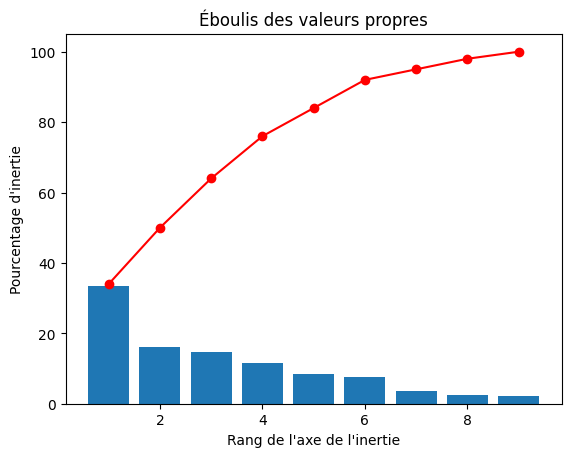

In [20]:
# Affichage des éboulis des valeurs propres (Matplotlib)
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum, c="red", marker="o")
plt.xlabel("Rang de l'axe de l'inertie")
plt.ylabel("Pourcentage d'inertie")
plt.title("Éboulis des valeurs propres")
plt.show(block=False)

In [21]:
# Affichage des éboulis des valeurs propres (Plotly)
fig = go.Figure()
fig.add_trace(go.Bar(x=list(x_list), y=scree, name="Variance par axe"))
fig.add_trace(
    go.Scatter(
        x=list(x_list),
        y=scree_cum,
        mode="lines+markers+text",
        name="Cumul",
        text=scree_cum,
    )
)
fig.update_layout(height=500, width=900)
fig.update_layout(
    title="Éboulis des valeurs propres",
    xaxis_title="Composantes principales",
    yaxis_title="Pourcentage de variance",
    paper_bgcolor="rgba(0,0,0,0)",
)
fig.show()

On remarque qu'il faut aller jusqu'à la 5e composantes pour avoir plus de 80% de la variance.

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.5 - Calcul des composantes</h3>
</div>

In [22]:
# Affichage de la matrice
pcs = pca.components_
pcs

array([[-0.10218871, -0.34559026,  0.43869233,  0.44809705,  0.49573705,
         0.41125379,  0.1488285 ,  0.19283996,  0.05158328],
       [-0.09082394,  0.12239133, -0.30366825,  0.00367187, -0.25259878,
         0.43244827,  0.70734729, -0.06159801,  0.35998797],
       [ 0.61417617, -0.23822639, -0.05778495, -0.26621737,  0.0086615 ,
         0.2124823 ,  0.28248653,  0.11426134, -0.59476633],
       [ 0.29130916,  0.31756482,  0.16424718, -0.11357506, -0.03636433,
        -0.08854243, -0.00297501,  0.80993812,  0.33052141],
       [ 0.68268493, -0.17550838,  0.05286726,  0.3751443 , -0.14885187,
        -0.12763687, -0.09254275, -0.33766792,  0.44562099],
       [ 0.14893149,  0.74886087,  0.46736791,  0.01999073,  0.13455726,
         0.12792134,  0.11393359, -0.35090992, -0.1661513 ],
       [-0.02785318,  0.22246343, -0.2729537 ,  0.75460661, -0.20783679,
        -0.19115658,  0.10614727,  0.22048017, -0.40765628],
       [ 0.03151291,  0.09594263, -0.09342283,  0.06816519, -0

In [23]:
# Affichage de la matrice version "pandas"
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8
0,-0.102189,-0.345590,0.438692,0.448097,0.495737,0.411254,0.148828,0.192840,0.051583
1,-0.090824,0.122391,-0.303668,0.003672,-0.252599,0.432448,0.707347,-0.061598,0.359988
2,0.614176,-0.238226,-0.057785,-0.266217,0.008662,0.212482,0.282487,0.114261,-0.594766
3,0.291309,0.317565,0.164247,-0.113575,-0.036364,-0.088542,-0.002975,0.809938,0.330521
4,0.682685,-0.175508,0.052867,0.375144,-0.148852,-0.127637,-0.092543,-0.337668,0.445621
5,0.148931,0.748861,0.467368,0.019991,0.134557,0.127921,0.113934,-0.350910,-0.166151
6,-0.027853,0.222463,-0.272954,0.754607,-0.207837,-0.191157,0.106147,0.220480,-0.407656
7,0.031513,0.095943,-0.093423,0.068165,-0.341517,0.715550,-0.585254,0.058037,-0.043481
8,0.170959,0.240204,-0.616895,0.014631,0.699248,0.098297,-0.149559,-0.028738,0.102459


In [24]:
# Affichage de la matrice avec les "indicateurs" avec arrondi
pcs.columns = indicateurs
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,population_totale_2017,croissance_pop_2012_2017_pct,pib_habitant_usd,indice_stabilite_politique,indice_score_epi,conso_volaille_kg_hab,conso_volaille_pct,importations_volaille_kg,tdi_volaille_pct
F1,-0.10,-0.35,0.44,0.45,0.50,0.41,0.15,0.19,0.05
F2,-0.09,0.12,-0.30,0.00,-0.25,0.43,0.71,-0.06,0.36
F3,0.61,-0.24,-0.06,-0.27,0.01,0.21,0.28,0.11,-0.59
F4,0.29,0.32,0.16,-0.11,-0.04,-0.09,-0.00,0.81,0.33
F5,0.68,-0.18,0.05,0.38,-0.15,-0.13,-0.09,-0.34,0.45
F6,0.15,0.75,0.47,0.02,0.13,0.13,0.11,-0.35,-0.17
F7,-0.03,0.22,-0.27,0.75,-0.21,-0.19,0.11,0.22,-0.41
F8,0.03,0.10,-0.09,0.07,-0.34,0.72,-0.59,0.06,-0.04
F9,0.17,0.24,-0.62,0.01,0.70,0.10,-0.15,-0.03,0.10


In [25]:
# Translation de la matrice
pcs.T.round(2)

,F1,F2,F3,F4,F5,F6,F7,F8,F9
population_totale_2017,-0.10,-0.09,0.61,0.29,0.68,0.15,-0.03,0.03,0.17
croissance_pop_2012_2017_pct,-0.35,0.12,-0.24,0.32,-0.18,0.75,0.22,0.10,0.24
pib_habitant_usd,0.44,-0.30,-0.06,0.16,0.05,0.47,-0.27,-0.09,-0.62
indice_stabilite_politique,0.45,0.00,-0.27,-0.11,0.38,0.02,0.75,0.07,0.01
indice_score_epi,0.50,-0.25,0.01,-0.04,-0.15,0.13,-0.21,-0.34,0.70
conso_volaille_kg_hab,0.41,0.43,0.21,-0.09,-0.13,0.13,-0.19,0.72,0.10
conso_volaille_pct,0.15,0.71,0.28,-0.00,-0.09,0.11,0.11,-0.59,-0.15
importations_volaille_kg,0.19,-0.06,0.11,0.81,-0.34,-0.35,0.22,0.06,-0.03
tdi_volaille_pct,0.05,0.36,-0.59,0.33,0.45,-0.17,-0.41,-0.04,0.10


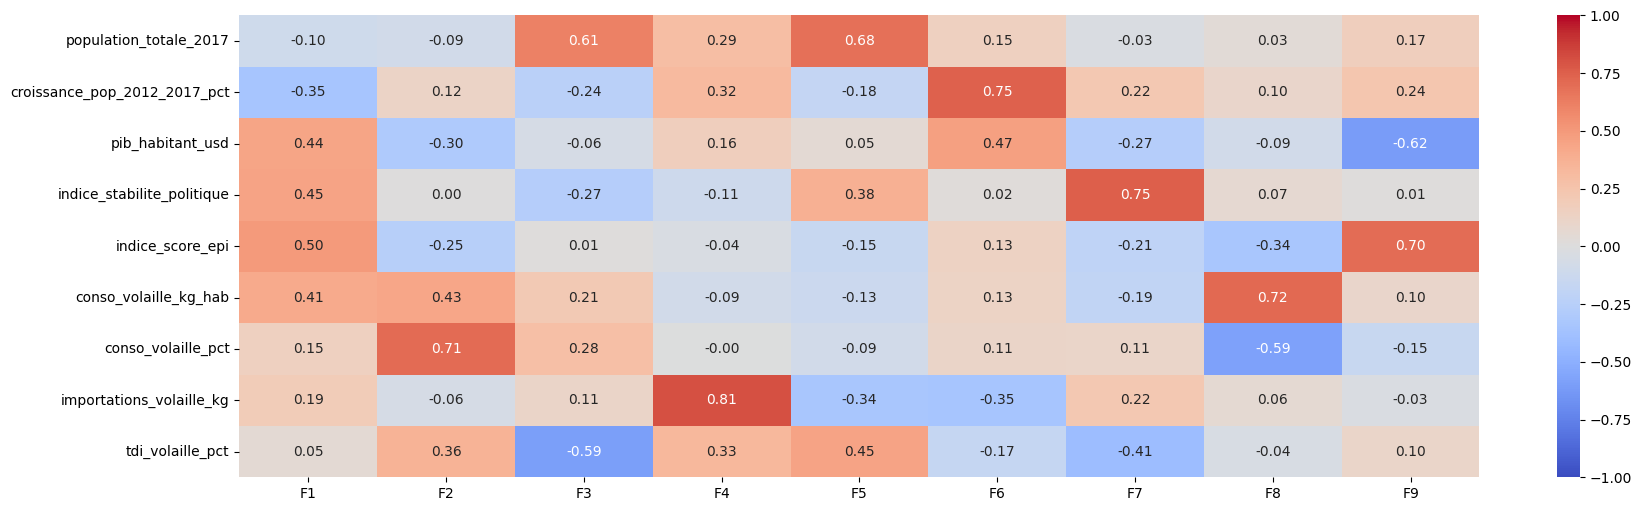

In [26]:
# Affichage de la heatmap correspondante
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")
plt.savefig("img/Heatmap_composantes_ACP.png", transparent=True)

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.6 - Graphique de corrélation</h3>
</div>

In [27]:
# Définition de nos axes x et y
x, y = 0, 1

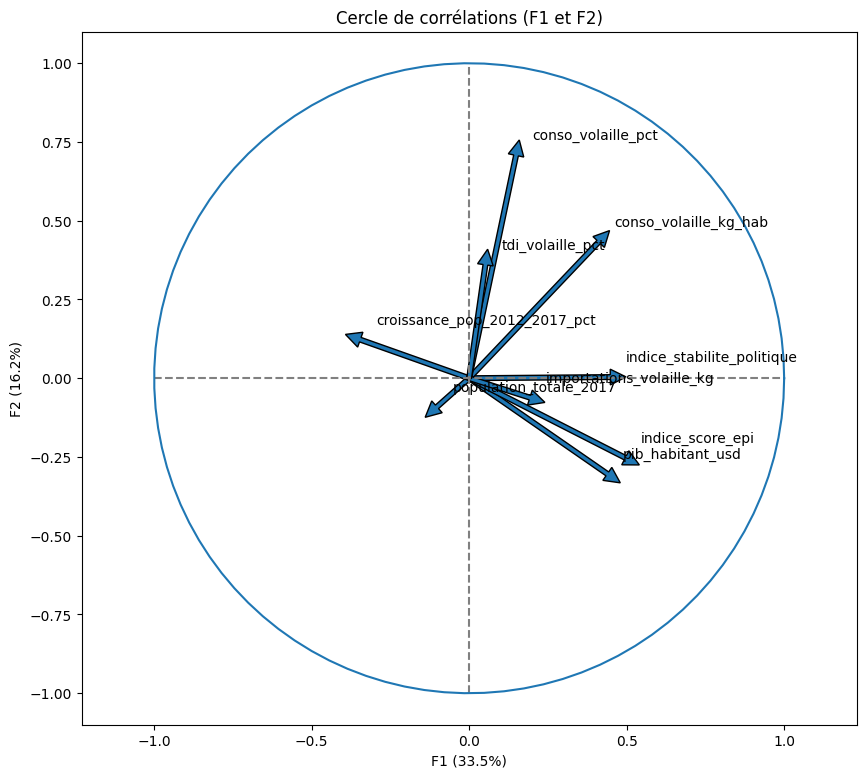

In [28]:
# Cercle de corrélations (F1 et F2)
fig, ax = plt.subplots(figsize=(10, 9))
for i in range(0, pca.components_.shape[1]):
    ax.arrow(
        0,
        0,
        pca.components_[0, i],
        pca.components_[1, i],
        head_width=0.05,
        head_length=0.05,
        width=0.015,
    )

    plt.text(pca.components_[0, i] + 0.05, pca.components_[y, i] + 0.05, indicateurs[i])

# Affichage des lignes horizontales et verticales
plt.plot([-1, 1], [0, 0], color="grey", ls="--")
plt.plot([0, 0], [-1, 1], color="grey", ls="--")

# Nom des axes avec le pourcentage d'inertie
plt.xlabel("F{} ({}%)".format(x + 1, round(100 * pca.explained_variance_ratio_[x], 1)))
plt.ylabel("F{} ({}%)".format(y + 1, round(100 * pca.explained_variance_ratio_[y], 1)))

# Le titre
plt.title("Cercle de corrélations (F{} et F{})".format(x + 1, y + 1))

# Le cercle
an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))

# Axes et display
plt.axis("equal")
plt.savefig("img/Cercle_Correlation01.png", transparent=True)
plt.show(block=False)

Les variables les plus **corrélées à F1** sont :
- l'indice de score EPI
- l'indice de stabilité politique
- le pib par habitant

Les variables les plus **corrélées à F2** sont :
- la consommation de volaille en % par rapport aux autres viandes
- la consommation de volaille en kg par an et par habitant

In [29]:
# Réalisation d'une fonction pour les autres graphiques


def correlation_graph(pca, x_y, indicateurs):
    # Extrait de x et y
    x, y = x_y

    # Taille de l'image et transparence
    fig, ax = plt.subplots(figsize=(10, 9))
    fig.patch.set_alpha(0.0)
    ax.set_facecolor("none")

    # Pour chaque composante
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(
            0,
            0,
            pca.components_[x, i],
            pca.components_[y, i],
            head_width=0.05,
            head_length=0.05,
            width=0.015,
        )

        # Les labels
        plt.text(
            pca.components_[0, i] + 0.05, pca.components_[y, i] + 0.05, indicateurs[i]
        )

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color="grey", ls="--")
    plt.plot([0, 0], [-1, 1], color="grey", ls="--")

    # Nom des axes avec le pourcentage d'inertie
    plt.xlabel(
        "F{} ({}%)".format(x + 1, round(100 * pca.explained_variance_ratio_[x], 1))
    )
    plt.ylabel(
        "F{} ({}%)".format(y + 1, round(100 * pca.explained_variance_ratio_[y], 1))
    )

    # Le titre
    plt.title("Cercle de corrélations (F{} et F{})".format(x + 1, y + 1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))

    # Axes et display
    plt.axis("equal")
    plt.savefig(
        "img/cercle_correlation_transparent.png",
        transparent=True,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show(block=False)

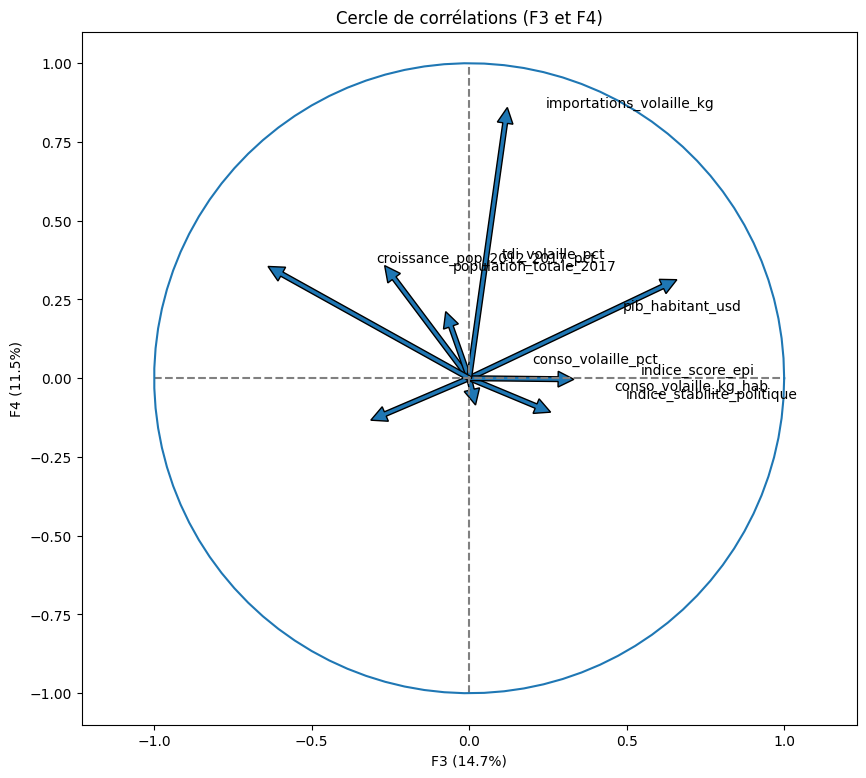

In [30]:
# Cercle de corrélations (F3 et F4)
correlation_graph(pca, (2, 3), indicateurs)

Les variables les plus **corrélées à F3** sont :
- le pib par habitant en US$

Les variables les plus **corrélées à F4** sont :
- l'importation de volaille en Kg

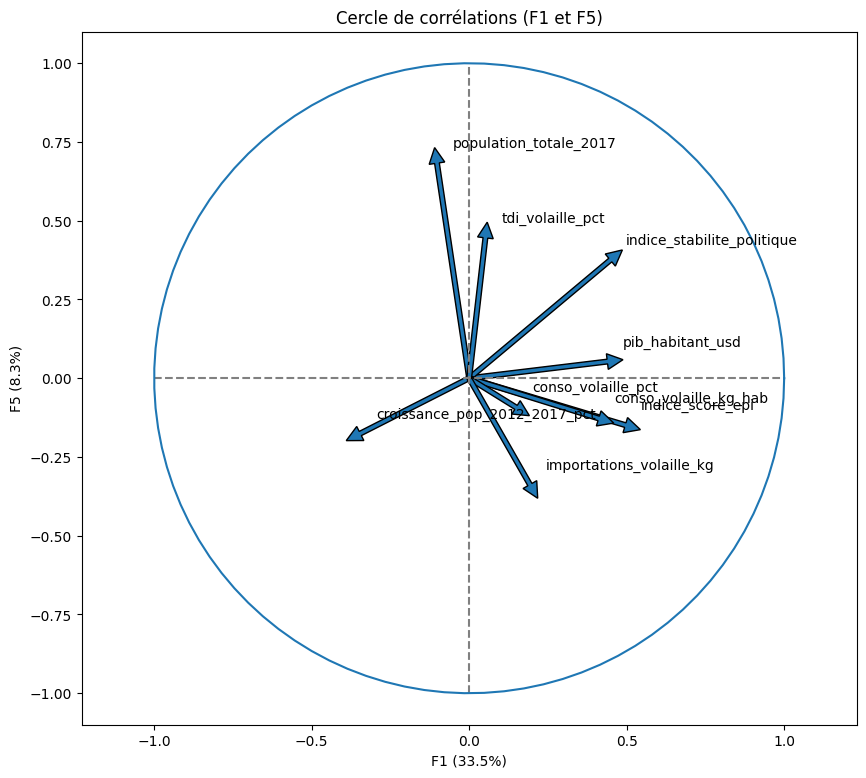

In [31]:
# Cercle de corrélations (F1 et F5)
correlation_graph(pca, (0, 4), indicateurs)

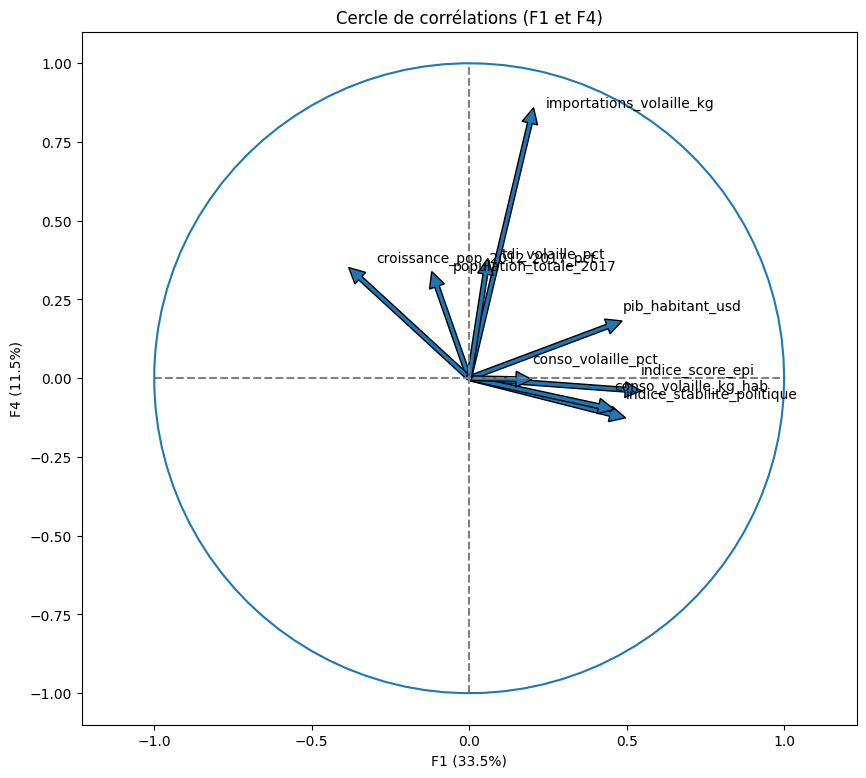

In [32]:
# Cercle de corrélations (F1 et F4)
correlation_graph(pca, (0, 3), indicateurs)

Bien que l'axe F2 explique la consommation globale de volaille, l'axe F4 est plus pertinent commercialement car il isole spécifiquement les dynamiques d'importation. 

Notre cible idéale se situe donc mathématiquement dans le quart supérieur droit (F1 / F4) : des pays riches, stables, et forts importateurs.

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">2.7 - Projection de nos dimensions</h3>
</div>

In [33]:
# Calcul des coordonnées de nos individus dans le nouvel espace
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[-3.62421082, -0.36623967, -0.36163998,  0.74791752, -0.65641327,
         0.2098238 , -1.69049288,  0.26979666, -0.22575242],
       [ 0.20331753,  1.17142468,  1.10249224,  1.84743181, -1.0388582 ,
        -0.75132915,  0.71252095,  0.72597901, -0.52193981],
       [ 0.66443216, -0.0250135 , -0.85008635, -0.44240443,  0.74517138,
        -1.24507371, -0.40060102, -0.3146182 ,  0.57966853],
       [-1.38045349, -0.68730455,  0.46212884, -0.41811368, -0.60554364,
         0.34181014, -0.03610788, -0.42123992,  0.31190467],
       [ 2.79635166, -1.96427237,  0.35568858,  3.48011477, -0.81350709,
        -1.08401646,  0.4133493 ,  0.02528152,  0.0466583 ]])

In [34]:
# Fonction pour la projection


def display_factorial_planes(
    X_projected,
    x_y,
    pca=None,
    labels=None,
    clusters=None,
    alpha=1,
    figsize=[10, 8],
    marker=".",
):

    # Transformation X_projected en np.array
    X_ = np.array(X_projected)

    # Definition la forme de la figure
    if not figsize:
        figsize = (7, 6)

    # Gestion les labels
    if labels is None:
        labels = []
    try:
        len(labels)
    except Exception as e:
        raise e

    # Vérification de la variable axis
    if not len(x_y) == 2:
        raise AttributeError("2 axes sont demandés")
    if max(x_y) >= X_.shape[1]:
        raise AttributeError("la variable axis n'est pas bonne")

    # Definition x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Vérification s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    plt.scatter(X_[:, x], X_[:, y], alpha=alpha, c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Calcul du % de variance
    if pca:
        v1 = str(round(100 * pca.explained_variance_ratio_[x])) + " %"
        v2 = str(round(100 * pca.explained_variance_ratio_[y])) + " %"
    else:
        v1 = v2 = ""

    # Nom des axes avec le pourcentage d'inertie
    ax.set_xlabel(f"F{x+1}{v1}")
    ax.set_ylabel(f"F{y+1}{v2}")

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() * 1.1
    y_max = np.abs(X_[:, y]).max() * 1.1

    # Bornage de x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom=-y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color="grey", alpha=0.8)
    plt.plot([0, 0], [-y_max, y_max], color="grey", alpha=0.8)

    # Affichage des labels des points
    if len(labels):
        for i, (_x, _y) in enumerate(X_[:, [x, y]]):
            plt.text(_x, _y + 0.05, labels[i], fontsize="14", ha="center", va="center")

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()

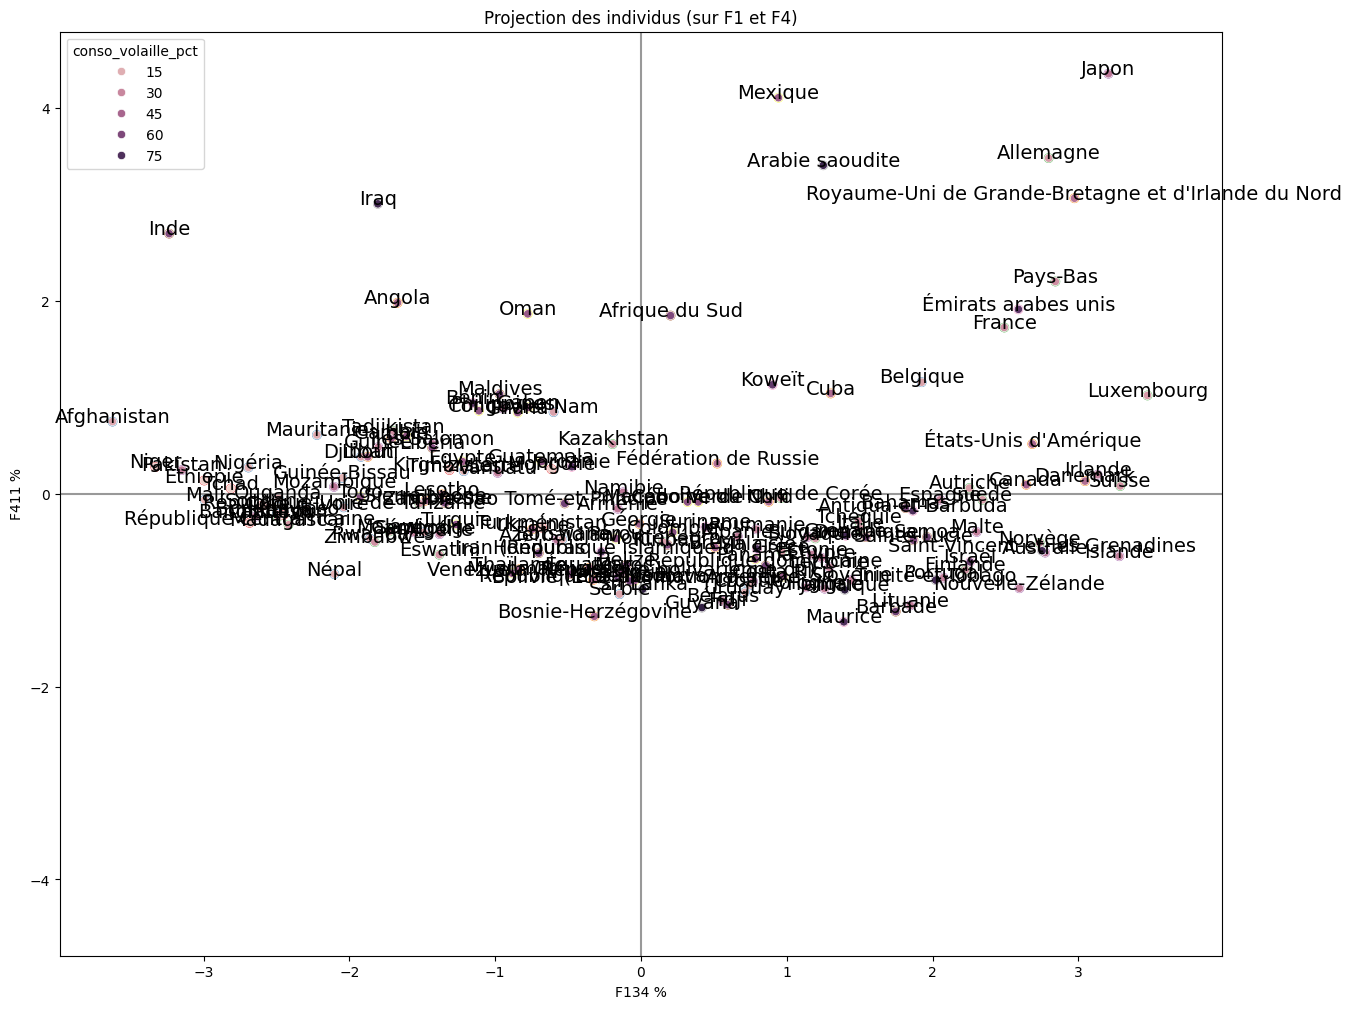

<Figure size 640x480 with 0 Axes>

In [35]:
# Projection des individus sur F1 et F4 en fonction de 'conso_volaille_pct'
x_y = [0, 3]
display_factorial_planes(
    X_proj,
    x_y,
    pca,
    labels=pays,
    clusters=df_analyse["conso_volaille_pct"],
    figsize=(15, 12),
    marker="o",
)
plt.savefig("img/projection_pays_transparente.png", transparent=True)

<div style="background-color: RGB(127,148,128);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 3 - Clustering avec la Classification Ascendante Hiérarchique (CAH)</h2>
</div>

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">3.1 - Calcul des distances avec la methode "Ward" (Linkage)</h3>
</div>

In [36]:
Z = linkage(X_scaled, method="ward")
Z[:5]

array([[ 11.        , 140.        ,   0.45919647,   2.        ],
       [ 93.        , 133.        ,   0.46487066,   2.        ],
       [ 25.        ,  28.        ,   0.49738402,   2.        ],
       [ 35.        , 162.        ,   0.58513922,   3.        ],
       [ 66.        , 119.        ,   0.60602369,   2.        ]])

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">3.2 - Dendrogram</h3>
</div>

In [37]:
# Scores de silhouette pour identifier la coupe du dendrogramme
range_n_clusters = range(2, 11)
scores_silhouette_cah = []

# Boucle pour tester chaque découpage
for n_clusters in range_n_clusters:
    cah_test = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    labels_test = cah_test.fit_predict(X_scaled)
    score_moyen = silhouette_score(X_scaled, labels_test)
    scores_silhouette_cah.append(score_moyen)

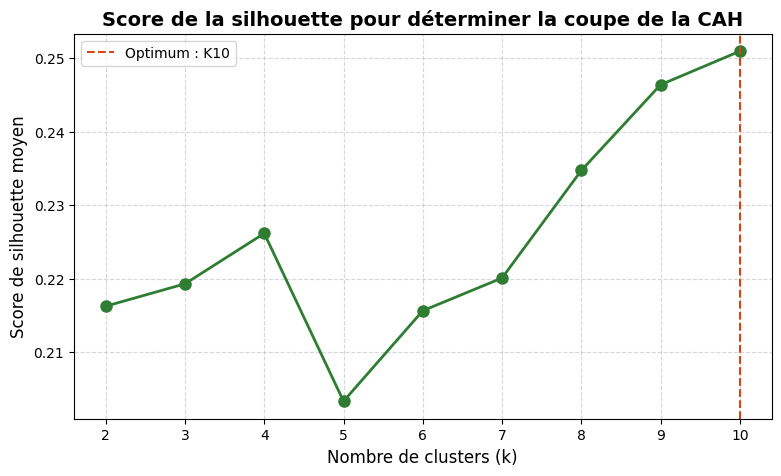

In [38]:
plt.figure(figsize=(9, 5))
plt.plot(
    range_n_clusters,
    scores_silhouette_cah,
    marker="o",
    color="#2E7D32",
    linewidth=2,
    markersize=8,
)

plt.title(
    "Score de la silhouette pour déterminer la coupe de la CAH",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Nombre de clusters (k)", fontsize=12)
plt.ylabel("Score de silhouette moyen", fontsize=12)

meilleur_k = range_n_clusters[scores_silhouette_cah.index(max(scores_silhouette_cah))]
plt.axvline(
    x=meilleur_k, color="#D84315", linestyle="--", label=f"Optimum : K{meilleur_k}"
)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

In [39]:
# Calcul du nombre de clusters en fonction de la hauteur de coupe du Dendrogramme
tests_hauteurs_coupe = [15, 14, 12, 10, 8, 6]
print("Simulateur de coupe du Dendrogramme :")
for h in tests_hauteurs_coupe:
    groupes = fcluster(Z, t=h, criterion="distance")
    nb_clusters = len(np.unique(groupes))
    print(f"Une coupe à Y = {h} génère {nb_clusters} clusters.")

Simulateur de coupe du Dendrogramme :
Une coupe à Y = 15 génère 4 clusters.
Une coupe à Y = 14 génère 6 clusters.
Une coupe à Y = 12 génère 8 clusters.
Une coupe à Y = 10 génère 8 clusters.
Une coupe à Y = 8 génère 10 clusters.
Une coupe à Y = 6 génère 12 clusters.


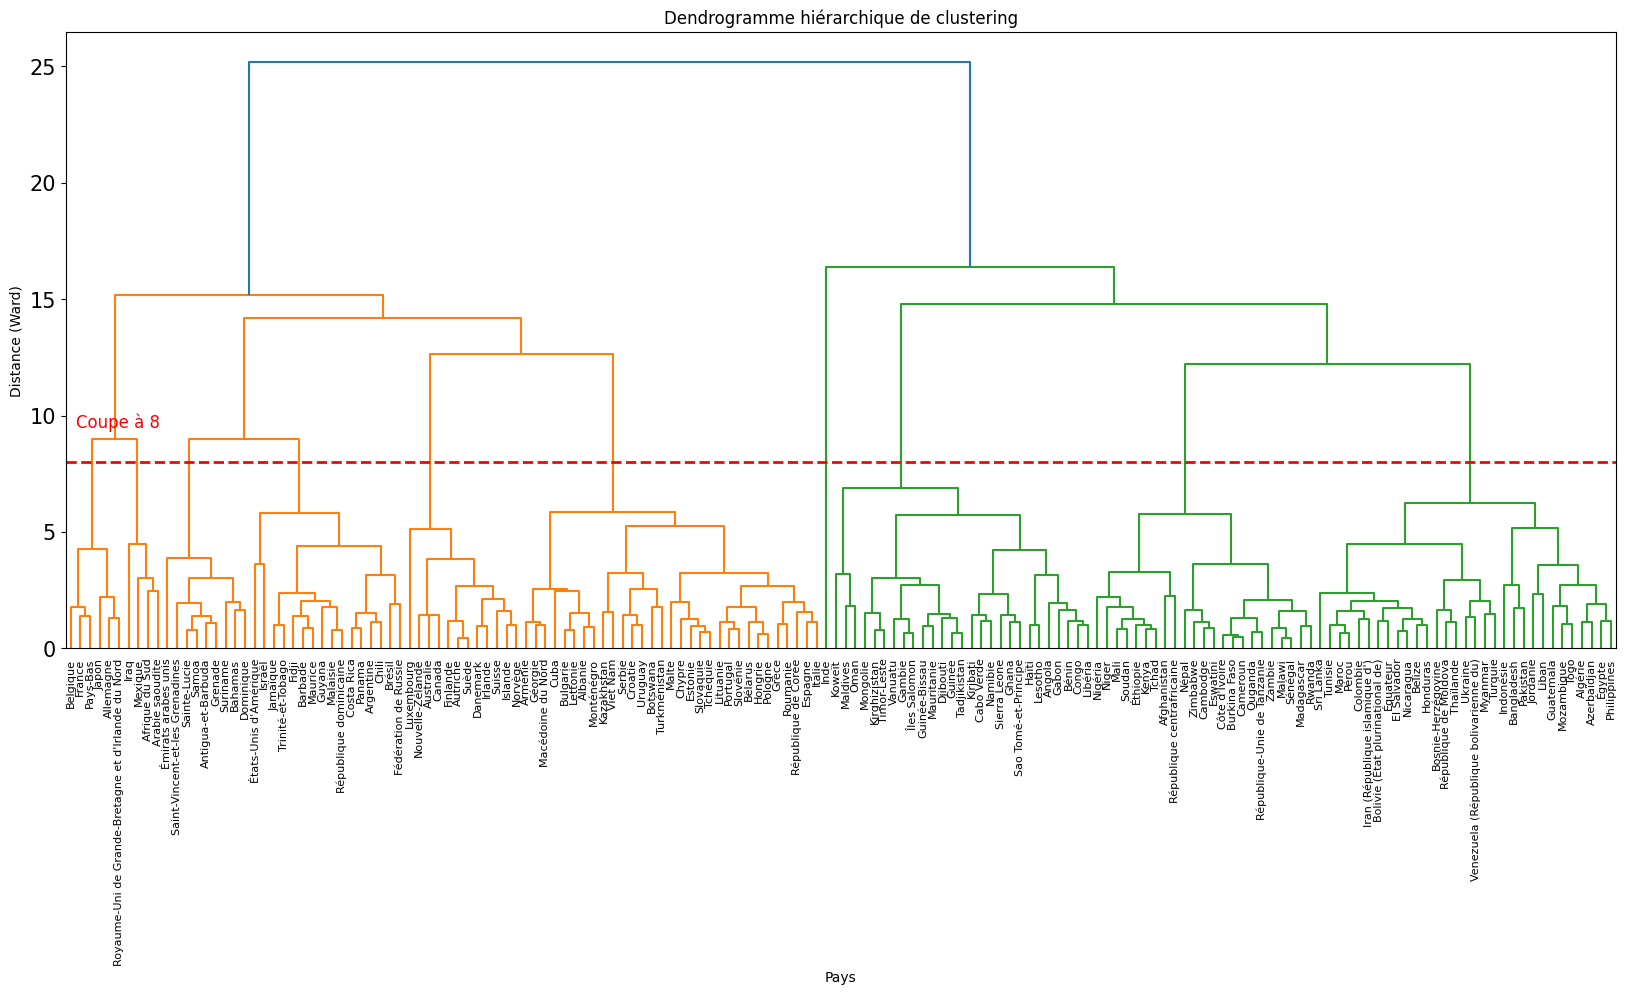

In [40]:
# Affichage du Dendrogramme
fig, ax = plt.subplots(1, 1, figsize=(20, 8))
_ = dendrogram(Z, ax=ax, labels=pays, orientation="top")
plt.title("Dendrogramme hiérarchique de clustering")
ax.set_xlabel("Pays")
ax.set_ylabel("Distance (Ward)")
ax.tick_params(axis="x", which="major", labelsize=8)
ax.tick_params(axis="y", which="major", labelsize=15)

hauteur_coupe = 8
plt.axhline(y=hauteur_coupe, color="red", linestyle="--", linewidth=2)
plt.text(
    x=11, y=hauteur_coupe + 1.5, s=f"Coupe à {hauteur_coupe}", color="red", fontsize=12
)
plt.savefig("img/dendrogram_transparente.png", transparent=True, dpi=300)
plt.show()

L'observation du dendrogramme (distance de Ward) couplée à l'optimisation du score de la Silhouette nous indique **une coupe mathématique optimale à 10 clusters.** 

Cela permet une segmentation fine et cohérente de nos 160 pays.

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">3.3 - Definition des clusters</h3>
</div>

In [41]:
# Définition du nombre de clusters
k = 10

In [42]:
clusters = fcluster(Z, k, criterion="maxclust")
clusters[:10]

array([8, 2, 6, 9, 1, 7, 3, 2, 4, 6], dtype=int32)

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">3.4 - Création et Profilage des 10 Clusters avec la moyenne</h3>
</div>

In [43]:
# Ajout des informations de cluster sur notre dataframe principal
df_analyse["cluster_cah"] = clusters

In [44]:
# Profilage avec la moyenne de chaque colonne pour chaque cluster
profil_clusters = df_analyse.groupby("cluster_cah").mean()

In [45]:
# Ajout du nombre de pays par cluster
profil_clusters["nb_pays"] = df_analyse.groupby("cluster_cah").size()

In [46]:
# Affichage du résultat
display(profil_clusters.style.background_gradient(cmap="YlGnBu").format("{:.2f}"))

,population_totale_2017,croissance_pop_2012_2017_pct,pib_habitant_usd,indice_stabilite_politique,indice_score_epi,conso_volaille_kg_hab,conso_volaille_pct,importations_volaille_kg,tdi_volaille_pct,nb_pays
cluster_cah,,,,,,,,,,
1,61695366.50,1.86,42858.72,0.61,78.29,20.96,28.88,690333333.33,33.09,6.00
2,63110260.00,11.40,11062.22,-1.01,51.27,31.63,67.04,669500000.00,45.90,4.00
3,1244816.11,3.41,15285.26,0.84,57.19,49.61,70.29,58777777.78,90.30,9.00
4,50455180.00,4.21,16351.14,0.19,61.33,42.01,61.23,45187500.00,8.32,16.00
5,9618241.92,4.82,63487.28,1.12,78.61,26.07,30.74,58916666.67,28.91,12.00
6,14517517.32,0.56,14514.68,0.41,65.32,19.21,29.09,74774193.55,38.27,31.00
7,5804374.78,13.52,4037.00,-0.03,46.86,11.14,41.40,51629629.63,82.57,27.00
8,34558835.87,13.32,1256.44,-0.96,43.77,2.43,16.68,3478260.87,9.50,23.00
9,49022490.45,7.40,4195.70,-0.81,54.14,17.23,53.42,32225806.45,8.14,31.00


In [47]:
for i in range(1, 11):

    print(f"-----Cluster CAH n° {i}-----")

    # filtre pour ne garder que les pays du cluster
    pays_du_cluster_cah = df_analyse[df_analyse["cluster_cah"] == i].index.tolist()

    # Assemblage des noms des pays avec un séparateur
    txt = " / ".join(pays_du_cluster_cah)

    # Affichage de la liste et le nombre total de pays
    print(txt)
    print(f"Total : {len(pays_du_cluster_cah)} pays\n")

-----Cluster CAH n° 1-----
Allemagne / Belgique / France / Japon / Pays-Bas / Royaume-Uni de Grande-Bretagne et d'Irlande du Nord
Total : 6 pays

-----Cluster CAH n° 2-----
Afrique du Sud / Arabie saoudite / Iraq / Mexique
Total : 4 pays

-----Cluster CAH n° 3-----
Antigua-et-Barbuda / Bahamas / Dominique / Émirats arabes unis / Grenade / Sainte-Lucie / Saint-Vincent-et-les Grenadines / Samoa / Suriname
Total : 9 pays

-----Cluster CAH n° 4-----
Argentine / Barbade / Brésil / Chili / Costa Rica / États-Unis d'Amérique / Fédération de Russie / Fidji / Guyana / Israël / Jamaïque / Malaisie / Maurice / Panama / République dominicaine / Trinité-et-Tobago
Total : 16 pays

-----Cluster CAH n° 5-----
Australie / Autriche / Canada / Danemark / Finlande / Irlande / Islande / Luxembourg / Norvège / Nouvelle-Zélande / Suède / Suisse
Total : 12 pays

-----Cluster CAH n° 6-----
Albanie / Arménie / Bélarus / Botswana / Bulgarie / Chypre / Croatie / Cuba / Espagne / Estonie / Géorgie / Grèce / Hongri

A la lecture de ce profilage CAH et de la liste des pays de ces clusters nous préconisons de nous concentrer sur les clusters 1, 2, 4 et 5 Clusters qui ont une majorité d'indicateurs avec des valeurs élevés.

In [48]:
# Selection des 4 clusters favoris
clusters_top_cah = [1, 2, 4, 5]
df_top_clusters_cah = df_analyse[df_analyse["cluster_cah"].isin(clusters_top_cah)]

In [49]:
tableau_cah = (
    df_top_clusters_cah.groupby("cluster_cah")
    .apply(lambda x: ", ".join(x.index))
    .reset_index()
)

tableau_cah.columns = ["Cluster CAH", "Pays dans le cluster"]

tableau_propre_cah = tableau_cah.style.set_properties(
    **{"text-align": "right", "white-space": "pre-wrap", "width": "300px"}
).hide(axis="index")

display(tableau_propre_cah)

Cluster CAH,Pays dans le cluster
1,"Allemagne, Belgique, France, Japon, Pays-Bas, Royaume-Uni de Grande-Bretagne et d'Irlande du Nord"
2,"Afrique du Sud, Arabie saoudite, Iraq, Mexique"
4,"Argentine, Barbade, Brésil, Chili, Costa Rica, États-Unis d'Amérique, Fédération de Russie, Fidji, Guyana, Israël, Jamaïque, Malaisie, Maurice, Panama, République dominicaine, Trinité-et-Tobago"
5,"Australie, Autriche, Canada, Danemark, Finlande, Irlande, Islande, Luxembourg, Norvège, Nouvelle-Zélande, Suède, Suisse"


In [50]:
# Visualisation pour comparer les 4 cluster favoris sur tous nos indicateurs

# Liste des colonnes à tracer (hors la colonne "Cluster")
indicateurs_a_tracer = [
    col
    for col in df_top_clusters_cah.columns
    if col not in ["cluster_cah", "cluster_kmeans"]
]

# Création de la boucle de visualisation
for indicateur in indicateurs_a_tracer:
    fig = px.box(
        df_top_clusters_cah,
        x="cluster_cah",
        y=indicateur,
        color="cluster_cah",
        hover_name=df_top_clusters_cah.index,
        title=f"Distribution par Cluster : {indicateur}",
    )
    fig.update_layout(
        width=800, height=450, showlegend=False, paper_bgcolor="rgba(0,0,0,0)"
    )
    fig.update_xaxes(type="category", categoryorder="category ascending")

    fig.show()

<div style="background-color: RGB(127,148,128);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 3 - Clustering avec K-Means</h2>
</div>

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">3.1 - Scaling des données</h3>
</div>


In [51]:
# Initialisation de K-Means avec 10 clusters
kmeans_10 = KMeans(n_clusters=10, random_state=42)

In [ ]:
# Entrainement de l'algorithme sur nos données  de K-Means avec 10 clusters
kmeans_10.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [53]:
# Calcul de son inertie
kmeans_10.inertia_

421.4884964516039

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">3.2 - Utilisation de la méthode du coude</h3>
</div>


In [54]:
# Définition d'une liste vide pour stocker nos inerties:
inertia_list = []

In [55]:
# Notre liste de nombre de clusters (plus loin pour justement bien voir la cassure):
k_list = range(1, 13)
list(k_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [56]:
# Pour chaque valeur de k, on entraine un k-means spécifique et on stocke son inertie : :
for i in k_list:
    modele_km = KMeans(n_clusters=i, random_state=42)
    modele_km.fit(X_scaled)
    inertia_list.append(modele_km.inertia_)

In [57]:
# Affichage de la liste des inerties
inertia_list

[1439.9999999999998,
 1091.5725259112962,
 930.2271679246747,
 855.2443915985664,
 734.6125892525466,
 662.4617815413998,
 532.042915364404,
 521.1258230483631,
 444.9811903870207,
 421.4884964516039,
 395.1593417487746,
 374.56112776682295]

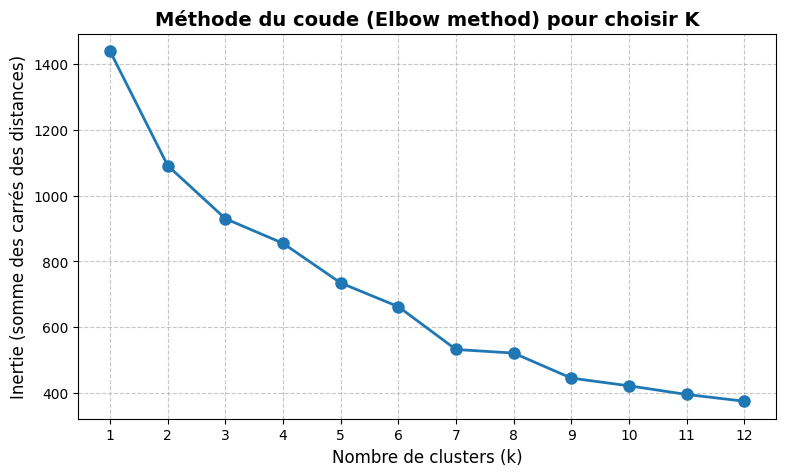

In [58]:
# Affichage du résultat

plt.figure(figsize=(9, 5))
plt.plot(
    list(k_list), inertia_list, marker="o", color="#1f77b4", linewidth=2, markersize=8
)

plt.title(
    "Méthode du coude (Elbow method) pour choisir K", fontsize=14, fontweight="bold"
)
plt.xlabel("Nombre de clusters (k)", fontsize=12)
plt.ylabel("Inertie (somme des carrés des distances)", fontsize=12)

plt.xticks(list(k_list))
plt.grid(linestyle="--", alpha=0.7)

plt.savefig("img/Elbow_method.png", transparent=True, dpi=300)
plt.show()

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">3.3 - Clusters</h3>
</div>

In [59]:
# Ré-entrainement de l'estimateur
kmeans_final = KMeans(n_clusters=10, random_state=42)
kmeans_final.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [60]:
# Ajout du résultat dans notre dataframe d'analyse
df_analyse["cluster_kmeans"] = kmeans_final.labels_ + 1

In [61]:
# Profilage avec le calcul de la moyenne des indicateurs par cluster
centroides_kmeans = df_analyse.groupby("cluster_kmeans").mean()

In [62]:
# Ajout du nombre pays par groupe
centroides_kmeans["nb_pays"] = df_analyse.groupby("cluster_kmeans").size()

In [63]:
# Affichage du dataframe
display(centroides_kmeans.round(2).style.background_gradient(cmap="YlGnBu"))

,population_totale_2017,croissance_pop_2012_2017_pct,pib_habitant_usd,indice_stabilite_politique,indice_score_epi,conso_volaille_kg_hab,conso_volaille_pct,importations_volaille_kg,tdi_volaille_pct,cluster_cah,nb_pays
cluster_kmeans,,,,,,,,,,,
1,1525944.400000,5.180000,16661.590000,0.750000,57.700000,49.270000,70.150000,66600000.000000,88.370000,3.400000,10
2,23345388.160000,12.030000,1882.020000,-0.340000,45.540000,3.710000,21.150000,19473684.210000,13.790000,7.680000,19
3,12222514.410000,-0.570000,14211.180000,0.330000,64.590000,20.030000,31.600000,70068965.520000,36.610000,6.210000,29
4,56670328.050000,7.420000,4862.340000,-0.930000,56.100000,16.960000,50.190000,52736842.110000,8.220000,8.740000,19
5,30157422.670000,4.540000,59678.590000,1.030000,78.190000,27.220000,31.070000,78466666.670000,30.600000,4.730000,15
6,1338676785.000000,5.760000,1930.140000,-0.770000,30.570000,2.220000,58.730000,0.000000,0.000000,10.000000,1
7,7530899.920000,13.620000,3285.490000,-0.140000,45.850000,9.970000,42.200000,68880000.000000,85.380000,6.800000,25
8,24109631.210000,5.960000,9860.140000,0.050000,58.970000,34.930000,64.900000,44166666.670000,10.190000,5.710000,24
9,73804422.000000,4.010000,35142.740000,0.250000,72.790000,27.000000,40.610000,785428571.430000,33.340000,1.290000,7


In [64]:
# Enregistrement du tableau des centroides en HTML
tableau_colore = centroides_kmeans.style.background_gradient(cmap="YlGnBu", axis=0)
tableau_colore.to_html("matrice_centroides.html")

In [65]:
for i in range(1, 11):

    print(f"-----Cluster K-Means n° {i}-----")

    # filtre pour ne garder que les pays du cluster
    pays_du_cluster_kmeans = df_analyse[
        df_analyse["cluster_kmeans"] == i
    ].index.tolist()

    # Assemblage des noms des pays avec un séparateur
    txt = " / ".join(pays_du_cluster_kmeans)

    # Affichage de la liste et le nombre total de pays
    print(txt)
    print(f"Total : {len(pays_du_cluster_kmeans)} pays\n")

-----Cluster K-Means n° 1-----
Antigua-et-Barbuda / Bahamas / Dominique / Émirats arabes unis / Grenade / Koweït / Sainte-Lucie / Saint-Vincent-et-les Grenadines / Samoa / Suriname
Total : 10 pays

-----Cluster K-Means n° 2-----
Botswana / Burkina Faso / Cambodge / Cameroun / Côte d'Ivoire / Eswatini / Guinée-Bissau / Madagascar / Malawi / Mozambique / Népal / Ouganda / République-Unie de Tanzanie / Rwanda / Sénégal / Turkménistan / Viet Nam / Zambie / Zimbabwe
Total : 19 pays

-----Cluster K-Means n° 3-----
Albanie / Arménie / Bélarus / Bosnie-Herzégovine / Bulgarie / Chypre / Croatie / Cuba / Espagne / Estonie / Géorgie / Grèce / Hongrie / Italie / Kazakhstan / Lettonie / Lituanie / Macédoine du Nord / Monténégro / Pologne / Portugal / République de Corée / République de Moldova / Roumanie / Serbie / Slovaquie / Slovénie / Tchéquie / Uruguay
Total : 29 pays

-----Cluster K-Means n° 4-----
Algérie / Azerbaïdjan / Égypte / Équateur / Fédération de Russie / Guatemala / Honduras / Indoné

L'algorithme K-Means confirme notre segmentation. 

L'analyse des centroïdes (moyennes des indicateurs par groupe) met en lumière 4 clusters particulièrement intéressants (Clusters 1, 3, 5 et 9), qui présentent les meilleurs ratios de pouvoir d'achat et de besoins d'importation.

In [66]:
# Selection des 4 clusters favoris
clusters_top_kmeans = [1, 3, 5, 9]
df_top_clusters_kmeans = df_analyse[
    df_analyse["cluster_kmeans"].isin(clusters_top_kmeans)
]
df_select_centroides = centroides_kmeans.loc[clusters_top_kmeans].copy()

In [67]:
# Changement des noms des colonnes pour la la matrice des centroides
noms_propres = {
    "population_totale_2017": "Pop. Totale",
    "croissance_pop_2012_2017_pct": "Croissance Pop (%)",
    "pib_habitant_usd": "PIB/hab ($)",
    "indice_stabilite_politique": "Stabilité Pol.",
    "indice_score_epi": "Score EPI",
    "conso_volaille_kg_hab": "Conso/hab (kg)",
    "conso_volaille_pct": "Part Volaille (%)",
    "importations_volaille_kg": "Importations (kg)",
    "tdi_volaille_pct": "TDI (%)",
}
df_select_centroides = df_select_centroides.rename(columns=noms_propres)

In [68]:
# Suppression de la colonne Cluster CAH
colonnes_a_enlever = ["cluster_cah"]
df_select_centroides = df_select_centroides.drop(
    columns=colonnes_a_enlever, errors="ignore"
)

In [69]:
# Normalisation pour que le dégradé s'applique par colonne
df_norm = (df_select_centroides - df_select_centroides.min()) / (
    df_select_centroides.max() - df_select_centroides.min()
)

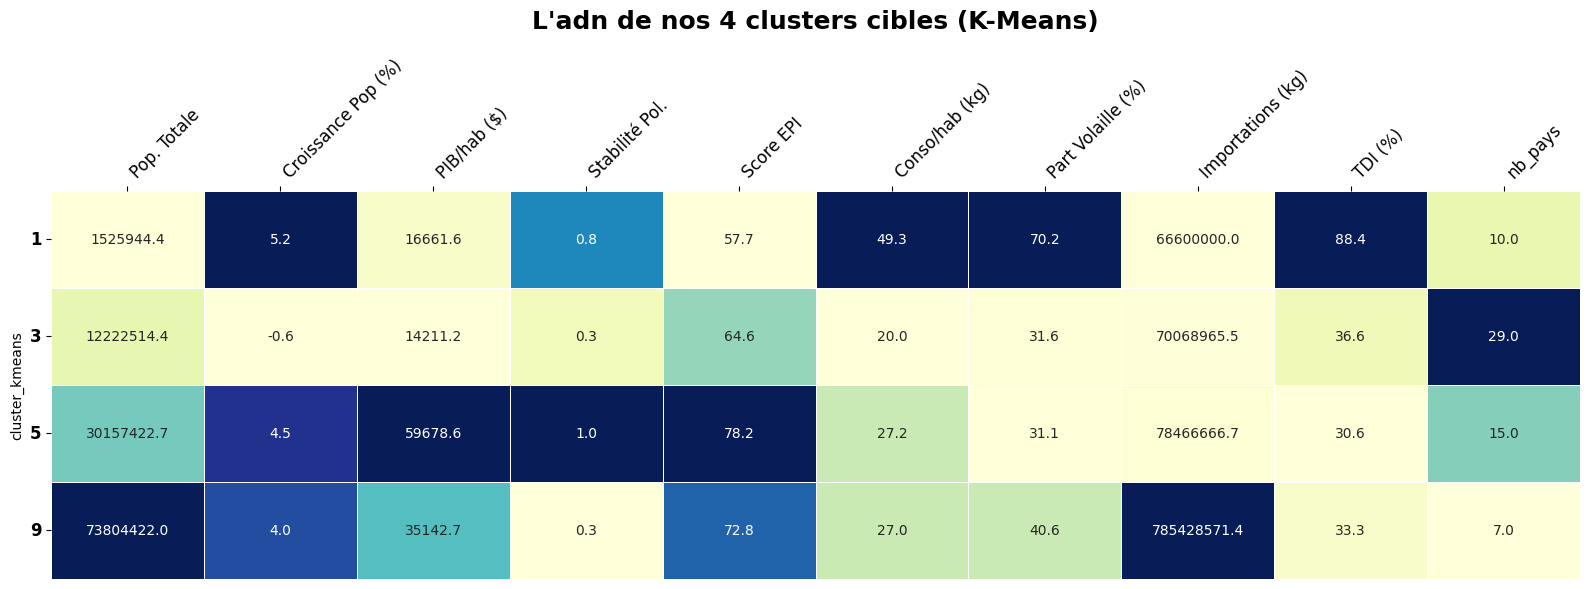

In [70]:
# Affichage des centroides des quatres clusters pour présentation
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    data=df_norm,
    annot=df_select_centroides,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar=False,
    ax=ax,
)
ax.xaxis.tick_top()
plt.title(
    "L'adn de nos 4 clusters cibles (K-Means)", fontsize=18, pad=20, fontweight="bold"
)
plt.xticks(rotation=45, ha="left", fontsize=12)
plt.yticks(rotation=0, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("img/matrice_centroides.png", dpi=300, transparent=True)
plt.show()

In [71]:
# Affichage de tous les pays de ces quatres clusters
tableau_kmeans = (
    df_top_clusters_kmeans.groupby("cluster_kmeans")
    .apply(lambda x: ", ".join(x.index))
    .reset_index()
)

tableau_kmeans.columns = ["Cluster K-Means", "Pays dans le cluster"]

tableau_propre_kmeans = tableau_kmeans.style.set_properties(
    **{"text-align": "right", "white-space": "pre-wrap", "width": "300px"}
).hide(axis="index")

display(tableau_propre_kmeans)

Cluster K-Means,Pays dans le cluster
1,"Antigua-et-Barbuda, Bahamas, Dominique, Émirats arabes unis, Grenade, Koweït, Sainte-Lucie, Saint-Vincent-et-les Grenadines, Samoa, Suriname"
3,"Albanie, Arménie, Bélarus, Bosnie-Herzégovine, Bulgarie, Chypre, Croatie, Cuba, Espagne, Estonie, Géorgie, Grèce, Hongrie, Italie, Kazakhstan, Lettonie, Lituanie, Macédoine du Nord, Monténégro, Pologne, Portugal, République de Corée, République de Moldova, Roumanie, Serbie, Slovaquie, Slovénie, Tchéquie, Uruguay"
5,"Australie, Autriche, Belgique, Canada, Danemark, États-Unis d'Amérique, Finlande, Irlande, Islande, Luxembourg, Malte, Norvège, Nouvelle-Zélande, Suède, Suisse"
9,"Allemagne, Arabie saoudite, France, Japon, Mexique, Pays-Bas, Royaume-Uni de Grande-Bretagne et d'Irlande du Nord"


In [72]:
# Visualisation pour comparer les 4 cluster favoris sur tous nos indicateurs

# Liste des colonnes à tracer (hors la colonne "Cluster")
indicateurs_a_tracer = [
    col
    for col in df_top_clusters_kmeans.columns
    if col not in ["cluster_cah", "cluster_kmeans"]
]

# Création de la boucle de visualisation
for indicateur in indicateurs_a_tracer:
    fig = px.box(
        df_top_clusters_kmeans,
        x="cluster_kmeans",
        y=indicateur,
        color="cluster_kmeans",
        hover_name=df_top_clusters_kmeans.index,
        title=f"K-Means (k=4) - Distribution par Cluster : {indicateur}",
    )
    fig.update_xaxes(type="category", categoryorder="category ascending")
    fig.update_layout(
        width=800, height=450, showlegend=False, paper_bgcolor="rgba(0,0,0,0)"
    )
    fig.show()

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">3.4 - Projection de nos clusters sur F1 & F4</h3>
</div>

In [73]:
# Relance de l'ACP pour calculer les coordonnées des pays
X_projected = pca.transform(X_scaled)

In [74]:
# Création d'un dataframe avec les coordonnées de l'ACP pour tous les pays avec F1(Colonne 0) et F4(Colonne 3)
df_pca_clusters = pd.DataFrame(
    {"F1": X_projected[:, 0], "F4": X_projected[:, 3]}, index=df_analyse.index
)
df_pca_clusters["cluster_kmeans"] = df_analyse["cluster_kmeans"]

In [75]:
# Conservation des 4 clusters
les_4_clusters = [1, 3, 5, 9]
df_pca_4cluster = df_pca_clusters[
    df_pca_clusters["cluster_kmeans"].isin(les_4_clusters)
].copy()

In [76]:
# Affichage du graphique
df_pca_4cluster["nom_cluster"] = "Cluster " + df_pca_4cluster["cluster_kmeans"].astype(
    str
)
ordre_clusters = sorted(df_pca_4cluster["nom_cluster"].unique())

fig = px.scatter(
    df_pca_4cluster,
    x="F1",
    y="F4",
    text=df_pca_4cluster.index,
    color="nom_cluster",
    title="Projection des 4 clusters (F1 : Développement & F4 : Importation de Volaille)",
    hover_name=df_pca_4cluster.index,
    color_discrete_sequence=["#41D5B0", "#6973FA", "#B273FA", "#EE6F5B"],
    category_orders={"nom_cluster": ordre_clusters},
)
fig.update_traces(
    textposition="top center",
    textfont_size=10,
    marker=dict(size=10),
    line=dict(width=1, color="white"),
)
fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.5)
fig.update_layout(
    width=900,
    height=600,
    paper_bgcolor="rgba(0,0,0,0)",
    legend_title_text="Groupes K-Means",
)

fig.show()

<div style="background-color: RGB(127,148,128);" >
<h2 style="margin: auto; padding: 20px; color:#fff; "> 4 - Recommandation stratégique</h2>
</div>

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">4.1 - Projection des deux clusters cibles</h3>
</div>

In [77]:
# Conservation des 2 clusters
les_2_clusters = [5, 9]
df_pca_2cluster = df_pca_clusters[
    df_pca_clusters["cluster_kmeans"].isin(les_2_clusters)
].copy()

In [78]:
# Affichage du graphique
df_pca_2cluster["nom_cluster"] = "Cluster " + df_pca_2cluster["cluster_kmeans"].astype(
    str
)
ordre_clusters = sorted(df_pca_2cluster["nom_cluster"].unique())

fig = px.scatter(
    df_pca_2cluster,
    x="F1",
    y="F4",
    text=df_pca_2cluster.index,
    color="nom_cluster",
    title="Projection des 2 clusters (F1 : Développement & F4 : Importation de Volaille)",
    hover_name=df_pca_2cluster.index,
    color_discrete_sequence=["#B273FA", "#EE6F5B"],
    category_orders={"nom_cluster": ordre_clusters},
)
fig.update_traces(
    textposition="top center",
    textfont_size=10,
    marker=dict(size=10),
    line=dict(width=1, color="white"),
)
fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.5)
fig.update_layout(
    width=900,
    height=600,
    paper_bgcolor="rgba(0,0,0,0)",
    legend_title_text="Groupes K-Means",
)

fig.show()

La projection de nos clusters favoris sur notre plan factoriel confirme que les clusters 5 et 9 se situent exactement dans notre cible d'exportation. 

Cela nous donne une liste restreinte de **22 pays** au potentiel économique validé par la donnée.

<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">4.2 - Matrice de validation CAH vs K-Means</h3>
</div>

In [79]:
# Définition du df_focus pour les Clusters CAH (1 et 5)
df_focus = df_analyse[df_analyse["cluster_cah"].isin([1, 5])]

In [80]:
# Création d'une matrice croisé entre la CAH et le K-Means
matrice_focus = pd.crosstab(df_focus["cluster_cah"], df_focus["cluster_kmeans"])

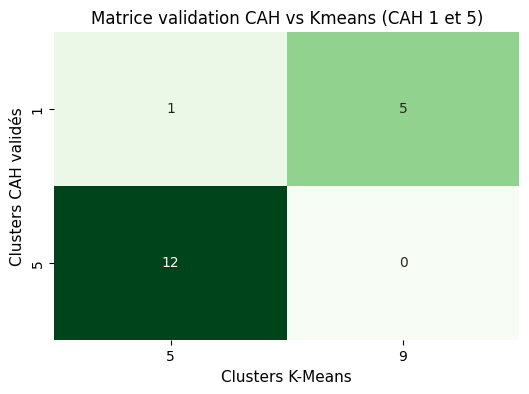

In [81]:
# Affichage de la matrice en heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(matrice_focus, annot=True, cmap="Greens", fmt="d", cbar=False)

plt.title("Matrice validation CAH vs Kmeans (CAH 1 et 5)", fontsize=12)
plt.xlabel("Clusters K-Means", fontsize=11)
plt.ylabel("Clusters CAH validés", fontsize=11)
plt.savefig("img/matrice_validation.png", transparent=True, dpi=300)
plt.show()

In [82]:
# Isolement des pays dans le cluster CAH-1 et dans les autres clusters K-Means (hors le cluster k-means 4)
pays_isole_cah1 = df_analyse[
    (df_analyse["cluster_cah"] == 1) & (df_analyse["cluster_kmeans"] != 9)
]

In [83]:
print("Les pays isolés du cluster CAH 1 :")
print("-" * 40)

# Affichage du noms des pays et du cluster K-Means correspondant
for pays in pays_isole_cah1.index:
    destination_kmeans = pays_isole_cah1.loc[pays, "cluster_kmeans"]
    print(f"{pays} : classé dans le K-Means n°{destination_kmeans}")

Les pays isolés du cluster CAH 1 :
----------------------------------------
Belgique : classé dans le K-Means n°5


<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">4.3 - Extraction des pays cibles</h3>
</div>

In [84]:
# Isolement des pays tes clusters cibles CAH (Clusters 1 et 5)
top_pays_cah = df_analyse[df_analyse["cluster_cah"].isin([1, 5])].index

In [85]:
# Isolement des pays tes clusters cibles K-Means (Clusters 5 et 9)
top_pays_kmeans = df_analyse[df_analyse["cluster_kmeans"].isin([5, 9])].index

In [86]:
# Comparaison des listes (avec "Sets")
pays_communs = top_pays_cah.intersection(top_pays_kmeans)
pays_indecis = top_pays_cah.symmetric_difference(top_pays_kmeans)

In [87]:
# Création d'un dataframe avec une Union
df_selection_pays = df_analyse.loc[
    top_pays_cah.union(top_pays_kmeans), ["cluster_cah", "cluster_kmeans"]
]

In [88]:
# Ajout d'un colonne pour le statut des pays (validé ou à creusé)
df_selection_pays["statut"] = "❌ A écarter"
df_selection_pays.loc[pays_communs, "statut"] = "✅ A confirmer"

In [89]:
df_selection_pays = df_selection_pays.sort_values(by="statut", ascending=False)
display(df_selection_pays)

,cluster_cah,cluster_kmeans,statut
pays,,,
États-Unis d'Amérique,4,5,❌ A écarter
Arabie saoudite,2,9,❌ A écarter
Mexique,2,9,❌ A écarter
Malte,6,5,❌ A écarter
Suède,5,5,✅ A confirmer
Suisse,5,5,✅ A confirmer
Royaume-Uni de Grande-Bretagne et d'Irlande du Nord,1,9,✅ A confirmer
Pays-Bas,1,9,✅ A confirmer
Nouvelle-Zélande,5,5,✅ A confirmer


In [90]:
print(f"Bilan : {len(pays_communs)} pays à analyser au cas par cas")
print(f"{len(pays_indecis)} pays à écarter")

Bilan : 18 pays à analyser au cas par cas
4 pays à écarter


<div style="border: 1px solid RGB(127,148,128);" >
<h3 style="margin: auto; padding: 20px; color: RGB(127,148,128); ">4.4 - Dataframe final et conclusion </h3>
</div>

In [91]:
# Selection des pays finaux
pays_selectionnes = [
    "Allemagne",
    "Belgique",
    "Pays-Bas",
    "Luxembourg",
    "Danemark",
    "France",
]

In [92]:
df_final = df_analyse.loc[pays_selectionnes].copy()

In [93]:
display(df_final.round(2))

,population_totale_2017,croissance_pop_2012_2017_pct,pib_habitant_usd,indice_stabilite_politique,indice_score_epi,conso_volaille_kg_hab,conso_volaille_pct,importations_volaille_kg,tdi_volaille_pct,cluster_cah,cluster_kmeans
pays,,,,,,,,,,,
Allemagne,82658409.0,2.08,45281.72,0.57,78.37,19.47,22.18,842000000.0,35.74,1,9
Belgique,11419748.0,3.02,44029.82,0.42,77.38,12.65,19.23,338000000.0,42.20,1,5
Pays-Bas,17021347.0,1.37,48987.32,0.91,75.46,20.33,26.82,608000000.0,35.60,1,9
Luxembourg,591910.0,11.50,110163.75,1.31,79.12,18.33,22.90,11000000.0,100.00,5,5
Danemark,5732274.0,2.16,57519.68,0.85,81.60,28.98,40.92,133000000.0,43.46,5,5
France,64842509.0,2.01,39655.01,0.27,83.95,22.90,27.58,506000000.0,22.43,1,9


In [94]:
# Nettoyage des colonnes
colonnes_a_afficher = [
    "population_totale_2017",
    "pib_habitant_usd",
    "conso_volaille_kg_hab",
    "importations_volaille_kg",
    "indice_stabilite_politique",
    "cluster_kmeans",
]

In [95]:
# Filtre des colonnes et trie par importation
df_final_presentation = df_final[colonnes_a_afficher].sort_values(
    by="importations_volaille_kg", ascending=False
)

In [96]:
# Affichage du tableau final
display(df_final_presentation.round(2))

,population_totale_2017,pib_habitant_usd,conso_volaille_kg_hab,importations_volaille_kg,indice_stabilite_politique,cluster_kmeans
pays,,,,,,
Allemagne,82658409.0,45281.72,19.47,842000000.0,0.57,9
Pays-Bas,17021347.0,48987.32,20.33,608000000.0,0.91,9
France,64842509.0,39655.01,22.90,506000000.0,0.27,9
Belgique,11419748.0,44029.82,12.65,338000000.0,0.42,5
Danemark,5732274.0,57519.68,28.98,133000000.0,0.85,5
Luxembourg,591910.0,110163.75,18.33,11000000.0,1.31,5


L'algorithme a identifié les marchés les plus viables, mais le bon sens logistique et écologique prime. 

En filtrant ces 22 pays par leur proximité géographique (zone de libre-échange européenne, livraison en 24h), un Top 5 se détache nettement, avec **l'Allemagne et la Belgique** comme marchés prioritaires pour l'amorçage puis le Luxembourg, les Pays-Bas et le Danemark dans un second temps.